Common genes: 11703

Finding variable genes for E14_16
Top genes: 50

Finding variable genes for E16_18
Top genes: 50

Finding variable genes for L1
Top genes: 50

Finding variable genes for L2
Top genes: 50

Finding variable genes for L3
Top genes: 50

Union genes: 186

Processing E14_16
Expression matrix: (15295, 183)
 Bootstrap 1/10
 Bootstrap 2/10
 Bootstrap 3/10
 Bootstrap 4/10
 Bootstrap 5/10
 Bootstrap 6/10
 Bootstrap 7/10
 Bootstrap 8/10
 Bootstrap 9/10
 Bootstrap 10/10


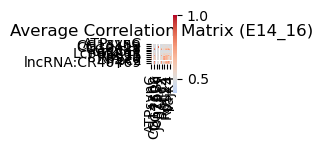


Processing E16_18
Expression matrix: (14634, 175)
 Bootstrap 1/10
 Bootstrap 2/10
 Bootstrap 3/10
 Bootstrap 4/10
 Bootstrap 5/10
 Bootstrap 6/10
 Bootstrap 7/10
 Bootstrap 8/10
 Bootstrap 9/10
 Bootstrap 10/10


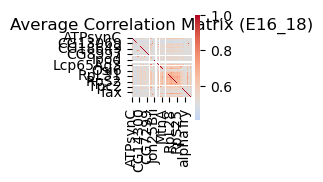


Processing L1
Expression matrix: (17787, 184)
 Bootstrap 1/10
 Bootstrap 2/10
 Bootstrap 3/10
 Bootstrap 4/10
 Bootstrap 5/10
 Bootstrap 6/10
 Bootstrap 7/10
 Bootstrap 8/10
 Bootstrap 9/10
 Bootstrap 10/10


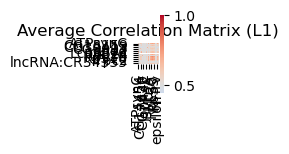


Processing L2
Expression matrix: (64658, 184)
 Bootstrap 1/10
 Bootstrap 2/10
 Bootstrap 3/10
 Bootstrap 4/10
 Bootstrap 5/10
 Bootstrap 6/10
 Bootstrap 7/10
 Bootstrap 8/10
 Bootstrap 9/10
 Bootstrap 10/10


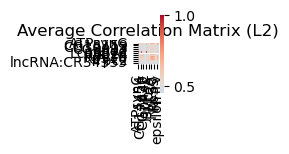


Processing L3
Expression matrix: (43310, 186)
 Bootstrap 1/10
 Bootstrap 2/10
 Bootstrap 3/10
 Bootstrap 4/10
 Bootstrap 5/10
 Bootstrap 6/10
 Bootstrap 7/10
 Bootstrap 8/10
 Bootstrap 9/10
 Bootstrap 10/10


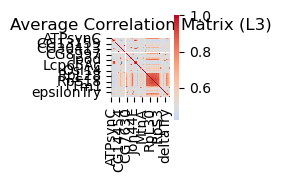


Pipeline finished successfully
E14_16: 15295 cells | 183 genes | 10 correlation matrices
E16_18: 14634 cells | 175 genes | 10 correlation matrices
L1: 17787 cells | 184 genes | 10 correlation matrices
L2: 64658 cells | 184 genes | 10 correlation matrices
L3: 43310 cells | 186 genes | 10 correlation matrices

Total correlation matrices created: 50


In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

###############################################################
# Parameters
###############################################################

top_n = 50
chunk_size = 500

n_bootstrap = 10
sample_fraction = 0.80

output_dir = r"C:\Users\mca52\Desktop\dataset\Bootstrap_Correlation_Matrices"

os.makedirs(output_dir, exist_ok=True)

###############################################################
# Load datasets
###############################################################

datasets = {
    "E14_16": sc.read_h5ad(r"C:\Users\mca52\Desktop\dataset\E14-16h_a_count_normal_stereoseq.h5ad"),
    "E16_18": sc.read_h5ad(r"C:\Users\mca52\Desktop\dataset\E16-18h_a_count_normal_stereoseq.h5ad"),
    "L1": sc.read_h5ad(r"C:\Users\mca52\Desktop\dataset\L1_a_count_normal_stereoseq.h5ad"),
    "L2": sc.read_h5ad(r"C:\Users\mca52\Desktop\dataset\L2_a_count_normal_stereoseq.h5ad"),
    "L3": sc.read_h5ad(r"C:\Users\mca52\Desktop\dataset\L3_b_count_normal_stereoseq.h5ad")
}

###############################################################
# Step 1 : Find common genes
###############################################################

common_genes = sorted(
    set.intersection(*[set(a.var_names) for a in datasets.values()])
)

print(f"Common genes: {len(common_genes)}")

###############################################################
# Step 2 : Select top variable genes
###############################################################

top_genes_per_stage = {}

for stage, adata in datasets.items():

    print(f"\nFinding variable genes for {stage}")

    X = adata.X
    n_genes = X.shape[1]

    gene_var = np.zeros(n_genes)

    for start in range(0, n_genes, chunk_size):

        end = min(start + chunk_size, n_genes)

        X_chunk = X[:, start:end]

        if hasattr(X_chunk, "toarray"):
            X_chunk = X_chunk.toarray()

        gene_var[start:end] = np.var(X_chunk, axis=0)

    gene_var = pd.Series(
        gene_var,
        index=adata.var_names
    )

    top = gene_var.sort_values(
        ascending=False
    ).head(top_n).index

    top_genes_per_stage[stage] = set(top)

    print(f"Top genes: {len(top)}")

###############################################################
# Step 3 : Union of variable genes
###############################################################

union_genes = sorted(
    set.union(*top_genes_per_stage.values())
)

print("\nUnion genes:", len(union_genes))

###############################################################
# Helper function
###############################################################

def get_expression(adata, genes):

    genes = [g for g in genes if g in adata.var_names]

    layer = adata[:, genes].layers["raw_counts"]

    if hasattr(layer, "toarray"):
        layer = layer.toarray()

    expr = pd.DataFrame(
        layer,
        index=adata.obs_names,
        columns=genes
    )

    return expr

###############################################################
# Step 4 : Bootstrap correlations
###############################################################

summary = {}

for stage, adata in datasets.items():

    print(f"\nProcessing {stage}")

    expr = get_expression(
        adata,
        union_genes
    )

    print("Expression matrix:", expr.shape)

    stage_dir = os.path.join(
        output_dir,
        stage
    )

    os.makedirs(stage_dir, exist_ok=True)

    correlation_sum = None

    for b in range(n_bootstrap):

        print(f" Bootstrap {b+1}/{n_bootstrap}")

        sample = expr.sample(
            frac=sample_fraction,
            replace=True,
            random_state=b
        )

        corr = sample.corr(method="pearson")

        corr = 0.5 * (1 + corr)

        filename = os.path.join(
            stage_dir,
            f"{stage}_bootstrap_{b+1}.csv"
        )

        corr.to_csv(filename)

        if correlation_sum is None:

            correlation_sum = corr.values

        else:

            correlation_sum += corr.values

    average_corr = correlation_sum / n_bootstrap

    average_corr = pd.DataFrame(
        average_corr,
        index=corr.index,
        columns=corr.columns
    )

    average_corr.to_csv(
        os.path.join(
            stage_dir,
            f"{stage}_AverageCorrelation.csv"
        )
    )

    plt.figure(figsize=(2,2))

    sns.heatmap(
        average_corr,
        cmap="coolwarm",
        center=0.5,
        square=True
    )

    plt.title(f"Average Correlation Matrix ({stage})")

    plt.tight_layout()

    plt.show()

    summary[stage] = {
        "cells": expr.shape[0],
        "genes": expr.shape[1],
        "bootstraps": n_bootstrap
    }

    del expr

###############################################################
# Final summary
###############################################################

print("\n==============================")
print("Pipeline finished successfully")
print("==============================")

total = 0

for stage in summary:

    total += summary[stage]["bootstraps"]

    print(
        f"{stage}: "
        f"{summary[stage]['cells']} cells | "
        f"{summary[stage]['genes']} genes | "
        f"{summary[stage]['bootstraps']} correlation matrices"
    )

print("\nTotal correlation matrices created:", total)